#Kmeans Clustering - Defence Based Experiment

**Enemy Territory Understanding**

Scenario: Enemy zones differ in activity intensity. Cluster areas into safe zones, suspicious zones, hostile zones using satellite/ground data.

Dataset idea:

Features: enemy_movement_frequency, explosion_reports, drone_activity, supply_lines_detected.

ML Use: Clustering → cluster regions into operational categories. (Safe, Suspicious, Hostile)

Note: Here I pick only two features for the development for demo to understand it better way. (More features would be but visualization would require dimensionality reduction (PCA))

#Importing the packages

In [ ]:
# =============================================
# Enemy Territory Understanding - KMeans Clustering (2 Features)
# =============================================

# 1. Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from ipywidgets import interact, IntSlider



#Loading the dataset and scaling the dataset

In [ ]:
# 2. Load dataset
df = pd.read_csv("/content/enemy_territory.csv")
print("Dataset Preview:\n", df.head())

# 3. Preprocessing - only two chosen features
X = df[["enemy_movement_frequency", "explosion_reports"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



   enemy_movement_frequency  explosion_reports  drone_activity  \
0                        12                 17              46   
1                        14                 18              68   
2                        43                  8              57   
3                         7                 12              35   
4                         9                  7              31   

   supply_lines_detected  
0                      2  
1                      0  
2                      4  
3                      3  
4                      2  


#Elbow method to find the optimal k-cluster value

***Inertia (Within-cluster SSE)***

(Elbow method).

Measures how tightly the points are grouped around the cluster center.

Lower = better.

Use the Elbow curve to find the best number of clusters.

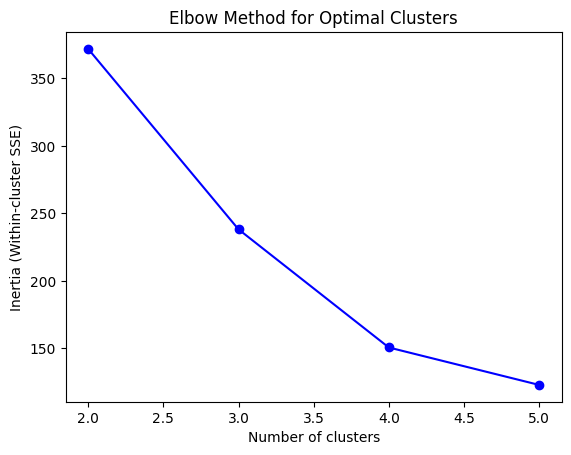

In [ ]:
# 4. Elbow method to choose cluster count
inertia = []
K = range(2, 6)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, 'bo-')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia (Within-cluster SSE)")
plt.title("Elbow Method for Optimal Clusters")
plt.show()


#Train a model and map with the cluster

In [ ]:
# 5. KMeans clustering with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

# Map cluster numbers to labels
zone_labels = {0: "Safe Zone", 1: "Suspicious Zone", 2: "Hostile Zone"}
df["zone"] = df["cluster"].map(zone_labels)

print("\nCluster Assignments:\n", df[["enemy_movement_frequency","explosion_reports","zone"]])




Cluster Assignments:
      enemy_movement_frequency  explosion_reports             zone
0                          12                 17  Suspicious Zone
1                          14                 18  Suspicious Zone
2                          43                  8     Hostile Zone
3                           7                 12  Suspicious Zone
4                           9                  7  Suspicious Zone
..                        ...                ...              ...
295                        26                  4        Safe Zone
296                        16                 14  Suspicious Zone
297                        37                 17     Hostile Zone
298                        35                 19     Hostile Zone
299                         0                 13  Suspicious Zone

[300 rows x 3 columns]


#Visualize the clusters

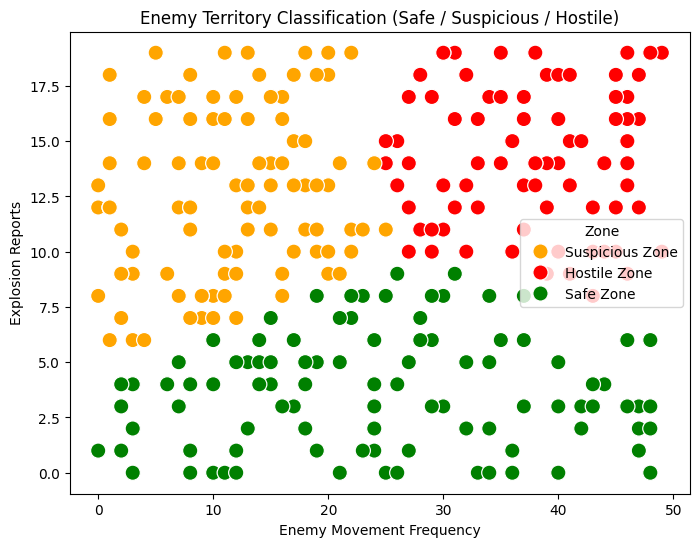

In [ ]:
# 6. Visualize clusters using original features
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df["enemy_movement_frequency"],
    y=df["explosion_reports"],
    hue=df["zone"],
    palette={"Safe Zone": "green", "Suspicious Zone": "orange", "Hostile Zone": "red"},
    s=120
)
plt.title("Enemy Territory Classification (Safe / Suspicious / Hostile)")
plt.xlabel("Enemy Movement Frequency")
plt.ylabel("Explosion Reports")
plt.legend(title="Zone")
plt.show()



#Manual validation

In [ ]:
# 7. Manual validation with interactive inputs
def predict_zone(movement, explosions):
    sample = pd.DataFrame([[movement, explosions]],
                          columns=["enemy_movement_frequency", "explosion_reports"])
    sample_scaled = scaler.transform(sample)
    cluster = kmeans.predict(sample_scaled)[0]
    mapping = {0: "Safe Zone", 1: "Suspicious Zone", 2: "Hostile Zone"}
    print("Predicted Cluster:", mapping[cluster])

interact(
    predict_zone,
    movement=IntSlider(min=0, max=300, step=10, value=50),
    explosions=IntSlider(min=0, max=30, step=1, value=5)
)


interactive(children=(IntSlider(value=50, description='movement', max=300, step=10), IntSlider(value=5, descri…

<function __main__.predict_zone(movement, explosions)>